<a href="https://colab.research.google.com/github/snehalpagare272005-jpg/GenerativeAI-Lab-Assignment./blob/main/Snehal_Pagare_GenerativeAILabAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice Lab Neural Network 1
## Neural Network Implementation from Scratch

**Institute:** MIT Academy of Engineering, Alandi, Pune  
**Class:** T.Y. B.Tech  
**Course:** Generative AI Lab  
**Department:** CSE AIML  

### Student Information
- **Name:** Snehal Pagare
- **PRN Number:** 202502110003
- **Batch:** A3
- **Date of Submission:** 19-08-2026



## Part A — Objective


The objective of this practical is to develop a basic feedforward neural network
using Python and NumPy without using built-in deep learning frameworks.

The implementation demonstrates the main stages involved in neural network
learning, including:

- Data preprocessing
- Parameter initialization
- Forward propagation
- Activation functions
- Loss calculation
- Backpropagation
- Gradient descent
- Model training
- Prediction and evaluation


## Part B — Problem Definition

In this practical, a neural network is developed to solve a multiclass
classification problem using the Iris dataset.

The model receives four measurements of an Iris flower as input and predicts
which of the three Iris species the flower belongs to.

### Classes

1. Iris-setosa
2. Iris-versicolor
3. Iris-virginica

### Input Features

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The problem is treated as a supervised learning problem where the network
learns the relationship between the flower measurements and their corresponding
species.

## Part C — Import Libraries

Only basic Python scientific-computing libraries are used. The neural-network mathematics is implemented manually using NumPy.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

print("Libraries imported successfully.")

Libraries imported successfully.


## Part D — Load Dataset

### Dataset Loading

The Iris dataset is loaded from the `iris.csv` file.

The dataset contains four numerical features and one categorical target
variable representing the species of the flower.

In [ ]:
data = pd.read_csv("iris.csv")

print("Dataset Shape:", data.shape)

display(data.head())

Dataset Shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Part E —Dataset Exploration


In [ ]:
print("Column Names:")
print(data.columns.tolist())

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nClass Distribution:")
print(data["Species"].value_counts())

Column Names:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing Values:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


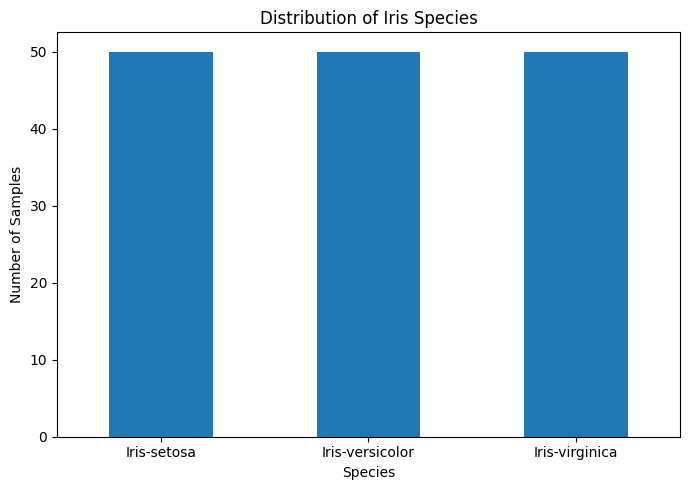

In [ ]:
plt.figure(figsize=(7, 5))

data["Species"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


## Part F — Data Preprocessing


Before training the neural network, the dataset is converted into a numerical
format.

The species names are encoded into numerical labels:

- Iris-setosa → 0
- Iris-versicolor → 1
- Iris-virginica → 2

The target values are then converted into one-hot encoded vectors.

The input features are standardized using the mean and standard deviation
calculated from the training data.

In [ ]:
features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

X_all = data[features].to_numpy(dtype=float)

label_map = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}

y_all = np.array([
    label_map[label]
    for label in data["Species"]
])

print("Feature Shape:", X_all.shape)
print("Target Shape:", y_all.shape)

Feature Shape: (150, 4)
Target Shape: (150,)


In [ ]:
# One-hot encoding

number_of_classes = 3

Y_all = np.zeros(
    (len(y_all), number_of_classes)
)

Y_all[
    np.arange(len(y_all)),
    y_all
] = 1

print("One-hot encoded target:")
print(Y_all[:5])

One-hot encoded target:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


## Part G — Train/Test Split


The dataset is divided into training and testing sets.

- 80% of the samples are used for training.
- 20% of the samples are used for testing.

The training data is used to learn the model parameters, while the test data
is kept separate for evaluating the final performance.


In [ ]:
rng = np.random.default_rng(7)

indices = rng.permutation(len(X_all))

split_point = int(0.80 * len(X_all))

train_indices = indices[:split_point]
test_indices = indices[split_point:]

X_train_raw = X_all[train_indices]
X_test_raw = X_all[test_indices]

Y_train = Y_all[train_indices]
Y_test = Y_all[test_indices]

y_train = y_all[train_indices]
y_test = y_all[test_indices]

print("Training samples:", len(X_train_raw))
print("Testing samples:", len(X_test_raw))

Training samples: 120
Testing samples: 30


##Feature Standardization

In [ ]:
mean_values = X_train_raw.mean(axis=0)
std_values = X_train_raw.std(axis=0)

std_values[std_values == 0] = 1

X_train = (
    X_train_raw - mean_values
) / std_values

X_test = (
    X_test_raw - mean_values
) / std_values

print("Standardized training data:")
print(X_train[:5])

Standardized training data:
[[-0.74640329  0.71741621 -1.26291919 -1.24523112]
 [ 0.36089829 -0.17240235  0.54125108  0.32082374]
 [ 2.32943444  1.60723477  1.72523782  1.36486031]
 [ 1.96033391 -0.61731162  1.38695589  0.97334659]
 [ 0.85303233 -0.17240235  0.87953301  1.10385117]]


##Neural Network Architecture


The network used in this practical contains three layers:

Input Layer → Hidden Layer → Output Layer

Architecture:

**4 → 8 → 3**

### Input Layer
Contains 4 neurons corresponding to the four Iris measurements.

### Hidden Layer
Contains 8 neurons and uses the ReLU activation function.

### Output Layer
Contains 3 neurons corresponding to the three Iris species.
The Softmax function converts the output values into class probabilities.

##Parameter Initialization

In [ ]:
def initialize_parameters(
    input_size=4,
    hidden_size=8,
    output_size=3
):

    rng = np.random.default_rng(7)

    W1 = rng.normal(
        0,
        np.sqrt(2 / input_size),
        (input_size, hidden_size)
    )

    b1 = np.zeros(
        (1, hidden_size)
    )

    W2 = rng.normal(
        0,
        np.sqrt(2 / hidden_size),
        (hidden_size, output_size)
    )

    b2 = np.zeros(
        (1, output_size)
    )

    return {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }


parameters = initialize_parameters()

for name, value in parameters.items():
    print(name, ":", value.shape)

W1 : (4, 8)
b1 : (1, 8)
W2 : (8, 3)
b2 : (1, 3)


## Activation Functions

### ReLU

ReLU is used in the hidden layer. It introduces non-linearity into the
network and helps the model learn more complex relationships.

### Softmax

Softmax is used in the output layer because this is a multiclass
classification problem. It converts the output scores into probabilities
whose total is equal to 1.

In [ ]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def softmax(x):

    shifted_x = x - np.max(
        x,
        axis=1,
        keepdims=True
    )

    exp_x = np.exp(shifted_x)

    return exp_x / np.sum(
        exp_x,
        axis=1,
        keepdims=True
    )

## Forward Propagation

During forward propagation, the input data passes through the network.

First, the input is multiplied by the first set of weights and the bias is
added. ReLU is then applied to the hidden layer.

The hidden-layer output is passed to the output layer. Finally, Softmax is
applied to obtain the probability of each class.

In [ ]:
def forward_propagation(X, parameters):

    W1 = parameters["W1"]
    b1 = parameters["b1"]

    W2 = parameters["W2"]
    b2 = parameters["b2"]

    Z1 = X @ W1 + b1

    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2

    A2 = softmax(Z2)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "A2": A2
    }

    return A2, cache

In [ ]:
probabilities, cache = forward_propagation(
    X_train[:5],
    parameters
)

print("Output probabilities:")
print(probabilities)

print("\nProbability sum for first sample:")
print(probabilities[0].sum())

Output probabilities:
[[2.23764389e-01 7.72640144e-04 7.75462971e-01]
 [3.42310181e-01 3.10754723e-01 3.46935096e-01]
 [4.00287839e-01 1.33573710e-01 4.66138452e-01]
 [3.60416097e-01 2.12315840e-01 4.27268063e-01]
 [3.51163062e-01 2.87851338e-01 3.60985600e-01]]

Probability sum for first sample:
1.0


## Loss Function

Categorical Cross-Entropy is used to measure the difference between the actual
class labels and the probabilities predicted by the network.

A lower loss indicates that the predicted probabilities are closer to the
correct class labels.

In [ ]:
def cross_entropy_loss(Y_true, Y_pred):

    epsilon = 1e-12

    Y_pred = np.clip(
        Y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        np.sum(
            Y_true * np.log(Y_pred),
            axis=1
        )
    )

    return loss

## Backpropagation

Backpropagation calculates how much each weight and bias contributes to the
prediction error.

The calculated gradients are then used by gradient descent to update the
network parameters.

This process allows the network to gradually reduce the training loss.

In [ ]:
def backward_propagation(
    X,
    Y,
    cache,
    parameters
):

    m = X.shape[0]

    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    # Output layer gradients
    dZ2 = A2 - Y

    dW2 = (
        A1.T @ dZ2
    ) / m

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    ) / m

    # Hidden layer gradients
    dA1 = dZ2 @ parameters["W2"].T

    dZ1 = (
        dA1 *
        relu_derivative(Z1)
    )

    dW1 = (
        X.T @ dZ1
    ) / m

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    ) / m

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return gradients

## Gradient Descent

Gradient descent is used to minimize the loss function.

After calculating the gradients using backpropagation, the weights and biases
are updated in the opposite direction of the gradients.

The learning rate controls the size of each parameter update.

In [ ]:
def update_parameters(
    parameters,
    gradients,
    learning_rate
):

    parameters["W1"] -= (
        learning_rate *
        gradients["dW1"]
    )

    parameters["b1"] -= (
        learning_rate *
        gradients["db1"]
    )

    parameters["W2"] -= (
        learning_rate *
        gradients["dW2"]
    )

    parameters["b2"] -= (
        learning_rate *
        gradients["db2"]
    )

## Model Training

The network is trained for multiple epochs.

For every epoch:

1. Forward propagation is performed.
2. The training loss is calculated.
3. Backpropagation calculates the gradients.
4. Gradient descent updates the parameters.

The loss is stored after each epoch so that the learning process can be
visualized later.

In [ ]:
parameters = initialize_parameters()

epochs = 1000
learning_rate = 0.08

loss_history = []

for epoch in range(1, epochs + 1):

    # Forward pass
    predictions, cache = forward_propagation(
        X_train,
        parameters
    )

    # Calculate loss
    loss = cross_entropy_loss(
        Y_train,
        predictions
    )

    loss_history.append(loss)

    # Backpropagation
    gradients = backward_propagation(
        X_train,
        Y_train,
        cache,
        parameters
    )

    # Parameter update
    update_parameters(
        parameters,
        gradients,
        learning_rate
    )

    if epoch == 1 or epoch % 100 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"Loss: {loss:.6f}"
        )

print("\nTraining completed.")

Epoch    1 | Loss: 1.476831
Epoch  100 | Loss: 0.379189
Epoch  200 | Loss: 0.245399
Epoch  300 | Loss: 0.167765
Epoch  400 | Loss: 0.123219
Epoch  500 | Loss: 0.097694
Epoch  600 | Loss: 0.082055
Epoch  700 | Loss: 0.071805
Epoch  800 | Loss: 0.064775
Epoch  900 | Loss: 0.059624
Epoch 1000 | Loss: 0.055678

Training completed.


## Loss Visualization

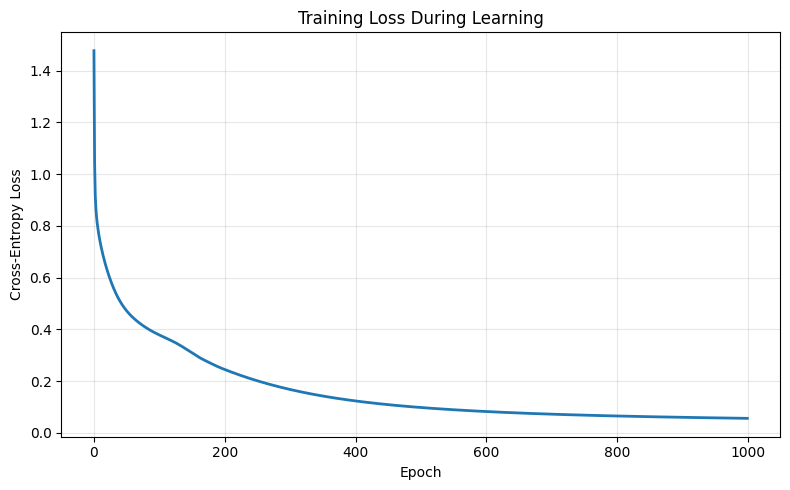

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history,
    linewidth=2
)

plt.title("Training Loss During Learning")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

## Prediction

After training, the test samples are passed through the trained network.

The class with the highest predicted probability is selected as the final
prediction.

In [ ]:
def predict(X, parameters):

    probabilities, _ = forward_propagation(
        X,
        parameters
    )

    return np.argmax(
        probabilities,
        axis=1
    )

In [ ]:
train_predictions = predict(
    X_train,
    parameters
)

test_predictions = predict(
    X_test,
    parameters
)

print("First 10 test predictions:")
print(test_predictions[:10])

print("\nActual labels:")
print(y_test[:10])

First 10 test predictions:
[1 2 2 2 0 2 0 2 1 1]

Actual labels:
[1 2 2 2 0 2 0 2 1 1]


## Accuracy

In [ ]:
train_accuracy = np.mean(
    train_predictions == y_train
)

test_accuracy = np.mean(
    test_predictions == y_test
)

print(
    f"Training Accuracy: "
    f"{train_accuracy * 100:.2f}%"
)

print(
    f"Testing Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Training Accuracy: 98.33%
Testing Accuracy: 96.67%


## Confusion Matrix

A confusion matrix is used to understand the classification performance for
each Iris species.

It shows how many samples from each actual class were correctly or incorrectly
classified by the neural network.

In [ ]:
confusion_matrix = np.zeros(
    (3, 3),
    dtype=int
)

for actual, predicted in zip(
    y_test,
    test_predictions
):

    confusion_matrix[
        actual,
        predicted
    ] += 1

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[ 6  0  0]
 [ 0 12  0]
 [ 0  1 11]]


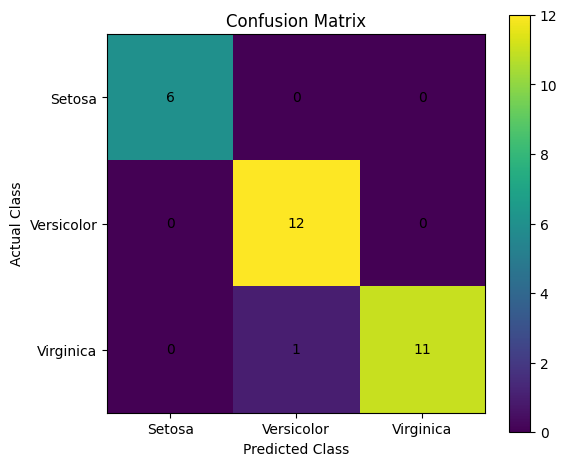

In [ ]:
class_names = [
    "Setosa",
    "Versicolor",
    "Virginica"
]

plt.figure(figsize=(6, 5))

plt.imshow(
    confusion_matrix
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(3),
    class_names
)

plt.yticks(
    range(3),
    class_names
)

for i in range(3):
    for j in range(3):

        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

##Prediction Comparison

In [ ]:
results = pd.DataFrame({
    "Actual": [
        class_names[i]
        for i in y_test
    ],

    "Predicted": [
        class_names[i]
        for i in test_predictions
    ]
})

results["Correct"] = (
    results["Actual"]
    == results["Predicted"]
)

display(results)

,Actual,Predicted,Correct
0,Versicolor,Versicolor,True
1,Virginica,Virginica,True
2,Virginica,Virginica,True
3,Virginica,Virginica,True
4,Setosa,Setosa,True
5,Virginica,Virginica,True
6,Setosa,Setosa,True
7,Virginica,Virginica,True
8,Versicolor,Versicolor,True
9,Versicolor,Versicolor,True


## Final Result

The feedforward neural network was successfully implemented from scratch using
Python and NumPy.

The model was trained using forward propagation, categorical cross-entropy,
backpropagation, and gradient descent.

The final model was evaluated on unseen test data using accuracy and a
confusion matrix. The training-loss graph shows how the model's error changed
during training.

The implementation demonstrates the fundamental working of a neural network
without relying on frameworks such as TensorFlow, Keras, or PyTorch.

## Conclusion

This practical provided an understanding of how a basic neural network can be
built and trained from scratch.

The implementation covered the complete learning pipeline, starting from data
preprocessing and parameter initialization and continuing through forward
propagation, loss calculation, backpropagation, and gradient-based parameter
updates.

The Iris classification problem was successfully used to demonstrate these
concepts in a simple and interpretable way.

## Declaration

I, **Snehal Pagare**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

**GitHub Repository Link:** https://github.com/snehalpagare272005-jpg/

**Signature:** Snehal Pagare

